In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

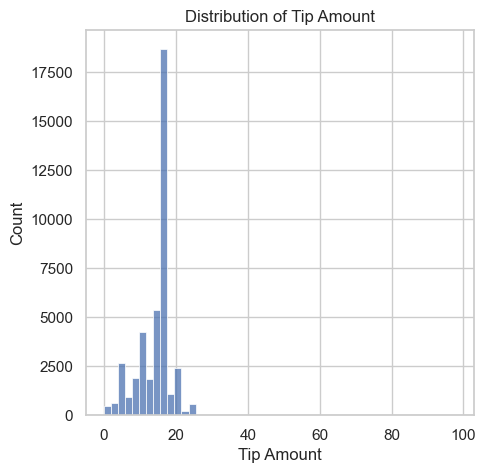

In [11]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
print(taxi.shape), 
display(taxi.head())
taxi.info()
display(taxi.describe())
display(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
  # (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize=(5,5))
sns.histplot(taxi["tip_amount"], bins=50)
plt.title("Distribution of Tip Amount")
# plt.xlim(50, 100)
plt.xlabel("Tip Amount")
plt.ylabel("Count")
plt.show()


The data has 41202 rows, 13 columns. there are no null values in the dataset. There are only two data types present; integers and floating point numbers. Even though they are all numbers, the purpose of some integers are rather categorical than numerical values. The class label, tip amount is a float, which hints that this problem is a regression problem instead of a classification one.

The distribution of the tip amount is skewed to the right, with most values falling in the 16 - 17 dollar range. A small number of tips were at the higher ends of the tip amount, with the highest tipped amount being 98 dollars. The presence of such high value tips in relation to this distribution suggests that there are potential outliers within the distribution.
There were no absolute zeros, but the smallest amount that was tipped was 0.01 dollars, which is about a cent.

In [15]:
from sklearn.preprocessing import StandardScaler

# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
clean_taxi = taxi.copy()

missing = taxi.isnull().sum()
clean_taxi = clean_taxi[clean_taxi["trip_distance"] > 0]
clean_taxi = clean_taxi[clean_taxi["fare_amount"] > 0]
clean_taxi = clean_taxi[clean_taxi["tip_amount"] >= 0]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

clean_taxi["fare_per_mile"] = clean_taxi["fare_amount"] / clean_taxi["trip_distance"]
clean_taxi["total_surcharges"] = clean_taxi["mta_tax"] + clean_taxi["tolls_amount"] + clean_taxi["improvement_surcharge"]

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

categoricals = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type"
]

clean_taxi_encoded = pd.get_dummies(clean_taxi, columns=categoricals, drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
scaler = StandardScaler()

We ensured that the trip distance and fare amount is greater than zero, we also ensured that the tip amount was not a negative number.

We derived the feature fare per mile, which can be used a uniform metric to measure rate of the fare per unit distance.

We also derived the total surchages, which can be used as a total sum of payment a user has to pay, apart from the actual fare amount.

We used the standard scaling because ...

In [16]:
from sklearn.model_selection import train_test_split

# TODO: Separate features (X) and target (y = tip_amount)
X = clean_taxi_encoded.drop(columns = "tip_amount")
y = clean_taxi_encoded["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)
#   (Explain in the reasoning box why scaling must be fit on train only.)

I used a ration of 60/40/40. A separate validation set is required for picking the best hypothesis function and tuning hyperparameters. The scaler and other imputation statistics must be fit on only the training data only because of data leakage. The model should not be exposed to computaions that require the input of the validation and testing data.

Linear Regression
Training: 4.7764 0.0624
Validation:   5.0465 0.0451
Testing:  5.0169 0.0496

Random Forest
Training: 2.8414 0.6682
Validation:   5.6513 -0.1975
Testing:  5.6216 -0.1932


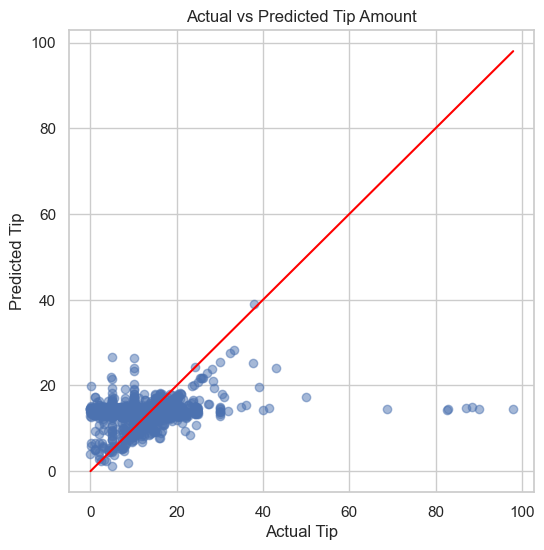

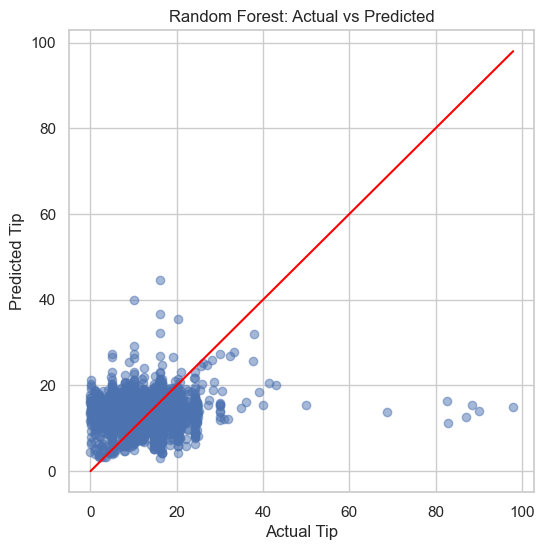

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train_scaled, y_train)


# TODO: Predict on train, validation, and test sets.
lin_train_pred = lin_model.predict(X_train_scaled)
lin_val_pred   = lin_model.predict(X_val_scaled)
lin_test_pred  = lin_model.predict(X_test_scaled)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_val_pred   = rf_model.predict(X_val_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# lin_train_rmse = mean_squared_error(y_train, lin_train_pred) ** 0.5
# lin_train_r2 = r2_score(y_train, lin_train_pred)

# lin_val_rmse = mean_squared_error(y_val, lin_val_pred) ** 0.5
# lin_val_r2 = r2_score(y_val, lin_val_pred)

# lin_test_rmse = mean_squared_error(y_test, lin_test_pred) ** 0.5
# lin_test_r2 = r2_score(y_test, lin_test_pred)


# rf_train_rmse = mean_squared_error(y_train, rf_train_pred) ** 0.5
# rf_train_r2 = r2_score(y_train, rf_train_pred)

# rf_val_rmse = mean_squared_error(y_val, rf_val_pred) ** 0.5
# rf_val_r2 = r2_score(y_val, rf_val_pred)

# rf_test_rmse = mean_squared_error(y_test, rf_test_pred) ** 0.5
# rf_test_r2 = r2_score(y_test, rf_test_pred)


def evaluate(y_true, y_pred):
  rmse = mean_squared_error(y_true, y_pred) ** 0.5
  r2 = r2_score(y_true, y_pred)
  return rmse, r2

lin_train_rmse, lin_train_r2 = evaluate(y_train, lin_train_pred)
lin_val_rmse, lin_val_r2 = evaluate(y_val, lin_val_pred)
lin_test_rmse, lin_test_r2 = evaluate(y_test, lin_test_pred)

rf_train_rmse, rf_train_r2 = evaluate(y_train, rf_train_pred)
rf_val_rmse, rf_val_r2 = evaluate(y_val, rf_val_pred)
rf_test_rmse, rf_test_r2 = evaluate(y_test, rf_test_pred)

print("Linear Regression")
print("Training:", round(lin_train_rmse, 4), round(lin_train_r2, 4))
print("Validation:  ", round(lin_val_rmse, 4), round(lin_val_r2, 4))
print("Testing: ", round(lin_test_rmse, 4), round(lin_test_r2, 4))

print("\nRandom Forest")
print("Training:", round(rf_train_rmse, 4), round(rf_train_r2, 4))
print("Validation:  ", round(rf_val_rmse, 4), round(rf_val_r2, 4))
print("Testing: ", round(rf_test_rmse, 4), round(rf_test_r2, 4))

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

plt.figure(figsize=(6,6))
plt.scatter(y_test, lin_test_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip Amount")
plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.show()


The linear regression model performed slightly better on the validation set.  

For the hyper parameters .... (n_estimators, max_depth).  

For Linear Regression, Even though the results were consistent, it was underfitting. For $R^2$, we obtainted 0.0624, 0.0451 and 0.0496 for training, validation, and testing respectively.  

For Random Forest Regression, The model was overfitting. For the training data, It had a promising R^2 of 0.6682. It drastically dropped for the validation data, with a value of -0.1975. The testing data also had the same trend, with an R^2 value of -0.1932.

To reduce the fitting for the above model, we can limit the tree depth, or increase the min samples per leaf.